# ECG Anomaly Detection using a Dense Autoencoder

**Deep Learning Lab Submission**

This notebook detects abnormal heartbeats in ECG signals using **unsupervised anomaly detection**.
A Dense (fully-connected) autoencoder is trained **only on normal heartbeats**. At test time,
both normal and abnormal heartbeats are fed through the trained model, and the **reconstruction
error** is used to flag anomalies: a model that has only ever seen normal beats will struggle
to reconstruct an abnormal one, producing a high error.

**Dataset:** ECG5000 (140 time-steps per heartbeat, downloaded directly in this notebook).


## 1. Setup & Data Loading

### 1.1 Why train only on *normal* data? (Unsupervised Anomaly Detection)

In many real-world settings (medical diagnostics, fraud detection, industrial fault detection),
**abnormal examples are rare and diverse** — there usually isn't enough labeled abnormal data to
train a reliable binary classifier, and new/unseen types of anomalies keep appearing.

The trick used here is to flip the problem around:

1. Train an **autoencoder** (encoder → bottleneck → decoder) to reconstruct its input as
   accurately as possible, using **only normal sequences**.
2. Because the model has *never* seen abnormal patterns during training, it learns a compressed
   representation that is specific to what "normal" looks like.
3. At test time, feed the model *any* sequence (normal or abnormal). Normal sequences will be
   reconstructed well (low error). Abnormal sequences — being outside the distribution the model
   learned — will be reconstructed poorly (high error).
4. A **threshold** on the reconstruction error becomes the anomaly decision boundary.

This is powerful because it needs **no abnormal labels at all** for training — only a labeled
test set to evaluate performance.

### 1.2 Imports and reproducibility

We fix random seeds for NumPy, Python, and TensorFlow and enable deterministic TensorFlow ops.
Exact numbers can still vary slightly across hardware / TensorFlow versions.

> This is an experimental, educational project -- not a clinical diagnostic system.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


### 1.3 Download and load the ECG5000 dataset

The dataset is a CSV with 140 columns of raw ECG time-step values plus a final label column.
Label `1` = normal heartbeat, any other value (2, 3, 4, 5) = a different kind of abnormal
heartbeat. For this lab we collapse all non-1 labels into a single "abnormal" class, since our
goal is *binary* anomaly detection (normal vs. not-normal).


In [2]:
DATA_URL = "http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv"

df = pd.read_csv(DATA_URL, header=None)
print("Raw shape:", df.shape)  # (rows, 141) -> 140 time steps + 1 label column
df.head()


Raw shape: (4998, 141)


,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


In [3]:
# Last column is the label; everything else is the 140-step sequence
raw_data = df.values
sequences = raw_data[:, :-1].astype("float32")
labels = raw_data[:, -1].astype("int32")

# Collapse to binary: 1 = normal, 0 = abnormal (all non-1 original labels)
binary_labels = (labels == 1).astype("int32")

print("Sequence length (time steps):", sequences.shape[1])
print("Total sequences:", sequences.shape[0])
print("Normal count:", binary_labels.sum())
print("Abnormal count:", (binary_labels == 0).sum())


Sequence length (time steps): 140
Total sequences: 4998
Normal count: 2919
Abnormal count: 2079


### 1.4 Train/test split of the *normal* data

- The **normal** sequences are split into a training part (80%) and a held-out part (20%).
- The **abnormal** sequences are kept completely out of training; they only appear in the test set.
- The split happens on the **raw** data *before* normalization, so the scaler can be fitted on
  training data only (see 1.5).


In [4]:
normal_mask = binary_labels == 1
abnormal_mask = binary_labels == 0

raw_normal = sequences[normal_mask]
raw_abnormal = sequences[abnormal_mask]

raw_normal_train, raw_normal_test = train_test_split(
    raw_normal, test_size=0.2, random_state=SEED
)
print("Normal train:", raw_normal_train.shape, "| held-out normal:", raw_normal_test.shape)
print("Abnormal (test only):", raw_abnormal.shape)


Normal train: (2335, 140) | held-out normal: (584, 140)
Abnormal (test only): (2079, 140)


### 1.5 Normalize (min-max scaling, fitted on training data only)

Autoencoders train more reliably on bounded inputs, and the decoder ends in a sigmoid, so
outputs live in `[0, 1]`. To avoid **data leakage**, the min and max are computed from the
**normal training split only** and then re-used unchanged for the held-out normal and abnormal
data. Consequently, test values may fall slightly outside `[0, 1]` -- that is expected and is
left as is (no clipping).


In [5]:
data_min = raw_normal_train.min()
data_max = raw_normal_train.max()

def min_max_scale(x, x_min=data_min, x_max=data_max):
    return (x - x_min) / (x_max - x_min)

normal_train = min_max_scale(raw_normal_train)
normal_test = min_max_scale(raw_normal_test)
abnormal_data = min_max_scale(raw_abnormal)
normal_data = min_max_scale(raw_normal)   # all normal beats, used only for plotting

# Final test set = held-out normal + all abnormal sequences
test_data = np.concatenate([normal_test, abnormal_data], axis=0)
test_labels = np.concatenate([
    np.ones(len(normal_test), dtype="int32"),    # 1 = normal
    np.zeros(len(abnormal_data), dtype="int32")  # 0 = abnormal
])

print("Train min/max:", normal_train.min(), normal_train.max())
print("Training set (normal only):", normal_train.shape)
print("Test set (normal + abnormal):", test_data.shape)
print("Test set counts [abnormal, normal]:", np.bincount(test_labels))


Train min/max: 0.0 1.0
Training set (normal only): (2335, 140)
Test set (normal + abnormal): (2663, 140)
Test set counts [abnormal, normal]: [2079  584]


### 1.6 Visualize example waveforms

A quick visual sanity check: normal heartbeats should have a fairly consistent, characteristic
shape, while abnormal ones show irregular or distorted waveforms.


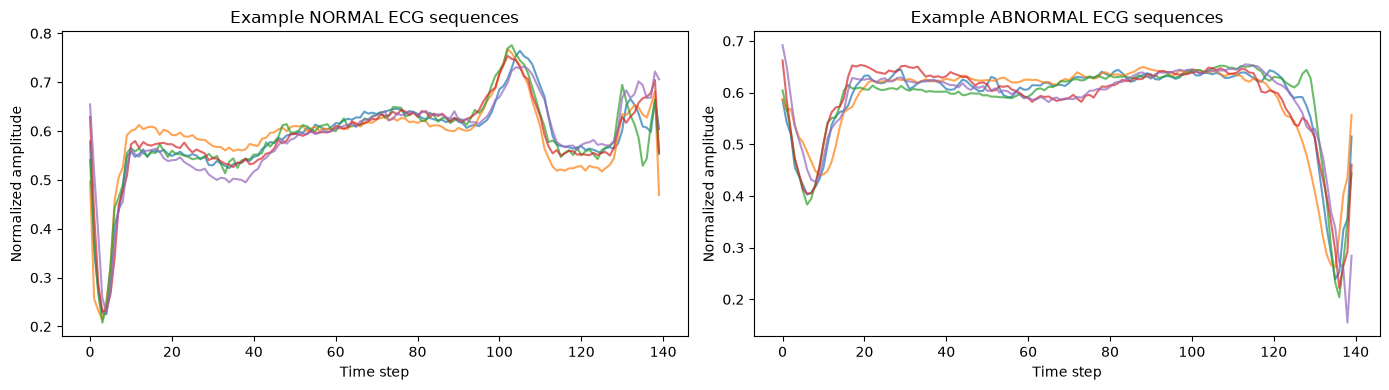

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i in range(5):
    axes[0].plot(normal_data[i], alpha=0.7)
axes[0].set_title("Example NORMAL ECG sequences")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Normalized amplitude")

for i in range(5):
    axes[1].plot(abnormal_data[i], alpha=0.7)
axes[1].set_title("Example ABNORMAL ECG sequences")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Normalized amplitude")

plt.tight_layout()
plt.show()


## 2. Dense (Fully-Connected) Autoencoder

### Theory

A **dense autoencoder** treats the ECG as a fixed-length feature vector and does not
explicitly model temporal dependencies between consecutive time steps, and learns to compress it through a narrow **bottleneck** layer, then
reconstruct it back to 140 values.

- **Encoder**: a stack of `Dense` layers that progressively reduce dimensionality
  (140 → 64 → 32 → 16), forcing the network to learn a compact latent representation of what
  a *normal* heartbeat looks like.
- **Decoder**: a mirrored stack of `Dense` layers that expands the latent vector back up to 140
  outputs, trying to reconstruct the original input.
- **Loss**: Mean Absolute Error (MAE) between input and reconstruction — this is also the
  anomaly score we'll use later.

The Dense Autoencoder treats the ECG as a fixed-length feature vector and does not explicitly
model temporal dependencies between consecutive time steps.
Output activation is sigmoid because the scaled inputs lie (approximately) in `[0, 1]`.


In [7]:
n_timesteps = normal_train.shape[1]

dense_encoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_timesteps,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
], name="dense_encoder")

dense_decoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(16,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(n_timesteps, activation="sigmoid"),
], name="dense_decoder")

dense_autoencoder = tf.keras.Sequential([dense_encoder, dense_decoder], name="dense_autoencoder")
dense_autoencoder.compile(optimizer="adam", loss="mae")
dense_autoencoder.summary()


Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_encoder (Sequential)      │ (None, 16)             │        11,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_decoder (Sequential)      │ (None, 140)            │        11,756 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,388 (91.36 KB)

 Trainable params: 23,388 (91.36 KB)

 Non-trainable params: 0 (0.00 B)

### Training

We train on `normal_train` only, reconstructing the same data as the target
(`autoencoder(x) ≈ x`). Keras' `validation_split=0.1` takes the last 10% of `normal_train`
(normal beats only) to monitor overfitting. Abnormal data is never used here.


In [8]:
dense_history = dense_autoencoder.fit(
    normal_train, normal_train,
    epochs=100,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)


Epoch 1/100


E0000 00:00:1791357471.045222  142872 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0884 - val_loss: 0.0648
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0490 - val_loss: 0.0354
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0298 - val_loss: 0.0258
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0244 - val_loss: 0.0239
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0233 - val_loss: 0.0233
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0230 - val_loss: 0.0232
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0228 - val_loss: 0.0230
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0227 - val_loss: 0.0228
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0224 - val_loss: 0.0223
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0219 - val_loss: 0.0215
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0211 - val_loss: 0.0206
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0204 - val_lo

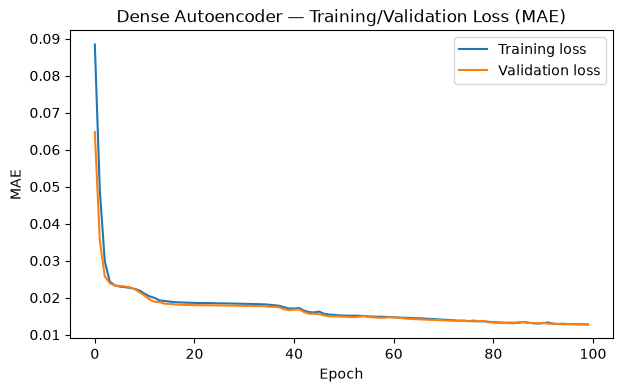

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(dense_history.history["loss"], label="Training loss")
plt.plot(dense_history.history["val_loss"], label="Validation loss")
plt.title("Dense Autoencoder — Training/Validation Loss (MAE)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()


## 3. Anomaly Detection & Evaluation

### Theory

For every test sequence, we compute the **reconstruction error** — the mean absolute error
between the original sequence and the model's reconstruction of it. Sequences the model
struggles to reconstruct (high error) are flagged as anomalies.

**Threshold selection**: we set the decision threshold using only the **training** distribution
of normal reconstruction errors: `threshold = mean(normal_train_errors) + std(normal_train_errors)`.
No test data or test labels are used to choose it (avoiding leakage), and it is not tuned on
the test set.

A test sequence is classified as **anomaly** if its reconstruction error exceeds this threshold.


In [10]:
def reconstruction_error(model, data):
    reconstructions = model.predict(data, verbose=0)
    return np.mean(np.abs(data - reconstructions), axis=1)

train_errors = reconstruction_error(dense_autoencoder, normal_train)
test_errors = reconstruction_error(dense_autoencoder, test_data)
threshold = train_errors.mean() + train_errors.std()

print(f"Dense AE threshold: {threshold:.4f}")


Dense AE threshold: 0.0187


E0000 00:00:1791357509.311626  142872 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


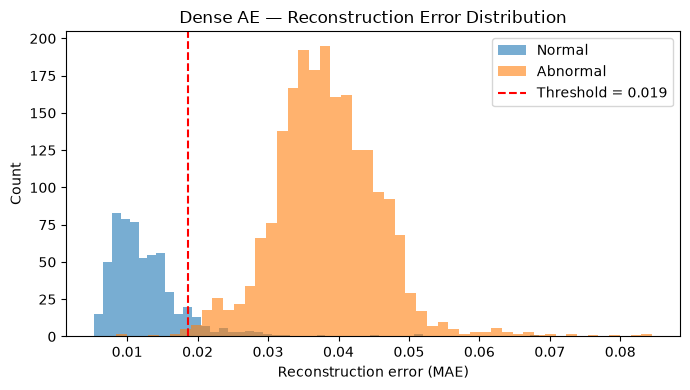

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(test_errors[test_labels == 1], bins=50, alpha=0.6, label="Normal")
plt.hist(test_errors[test_labels == 0], bins=50, alpha=0.6, label="Abnormal")
plt.axvline(threshold, color="red", linestyle="--", label=f"Threshold = {threshold:.3f}")
plt.title("Dense AE — Reconstruction Error Distribution")
plt.xlabel("Reconstruction error (MAE)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


### Classification and metrics

Recall that `test_labels == 1` means *normal* and `test_labels == 0` means *abnormal*. A
predicted **anomaly** occurs when reconstruction error exceeds the threshold, so we map that to
`prediction == 0` (abnormal) to align with the label convention, then compute standard
classification metrics with **abnormal as the positive class** (`pos_label=0`).


In [12]:
def classify(errors, threshold):
    # error > threshold -> predicted abnormal (0), else predicted normal (1)
    return (errors <= threshold).astype("int32")

preds = classify(test_errors, threshold)

acc = accuracy_score(test_labels, preds)
prec = precision_score(test_labels, preds, pos_label=0)   # positive class = abnormal
rec = recall_score(test_labels, preds, pos_label=0)
f1 = f1_score(test_labels, preds, pos_label=0)
print(f"Accuracy:             {acc:.4f}")
print(f"Precision (abnormal): {prec:.4f}")
print(f"Recall (abnormal):    {rec:.4f}")
print(f"F1 (abnormal):        {f1:.4f}")


Accuracy:             0.9756
Precision (abnormal): 0.9737
Recall (abnormal):    0.9957
F1 (abnormal):        0.9845


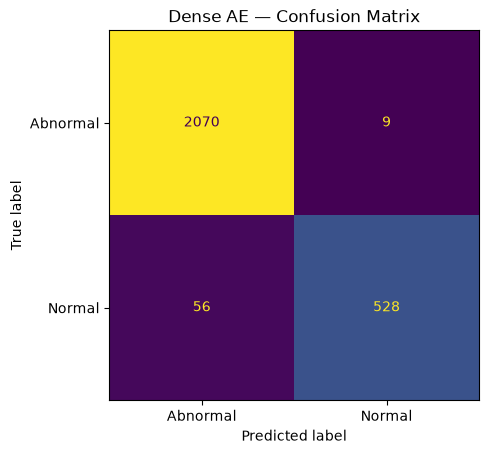

In [13]:
ConfusionMatrixDisplay(
    confusion_matrix(test_labels, preds, labels=[0, 1]),
    display_labels=["Abnormal", "Normal"]
).plot(colorbar=False)
plt.title("Dense AE — Confusion Matrix")
plt.show()


### ROC curve and AUC

The ROC curve sweeps the anomaly threshold across all possible values and plots the true
positive rate vs. false positive rate for detecting the abnormal class — a threshold-independent
view of the model's separative power, summarized by the AUC. The raw reconstruction error is
used as the anomaly score (higher error = more anomalous) with "abnormal" as the positive
class; scores are not altered in any way.


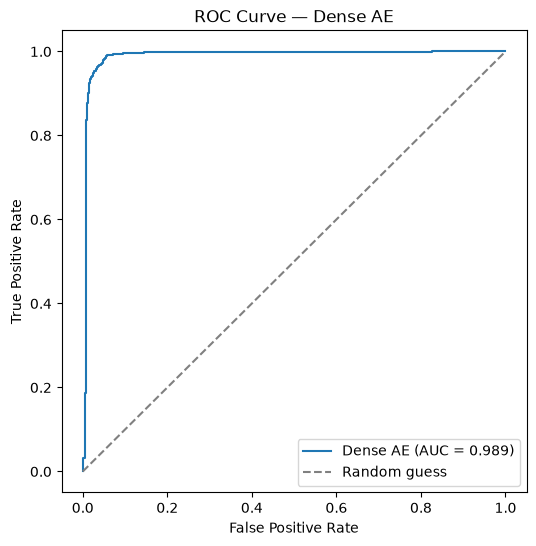

Dense AE AUC: 0.9892


In [14]:
# Use (1 - label) as the "is abnormal" indicator, and raw reconstruction error as the score
fpr, tpr, _ = roc_curve(1 - test_labels, test_errors)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Dense AE (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Dense AE")
plt.legend()
plt.show()

print(f"Dense AE AUC: {roc_auc:.4f}")


## 4. Visualization

### Original vs. reconstructed sequences

Overlaying a few normal and abnormal test examples with their reconstructions makes the
reconstruction gap directly visible.


E0000 00:00:1791357522.604943  142872 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


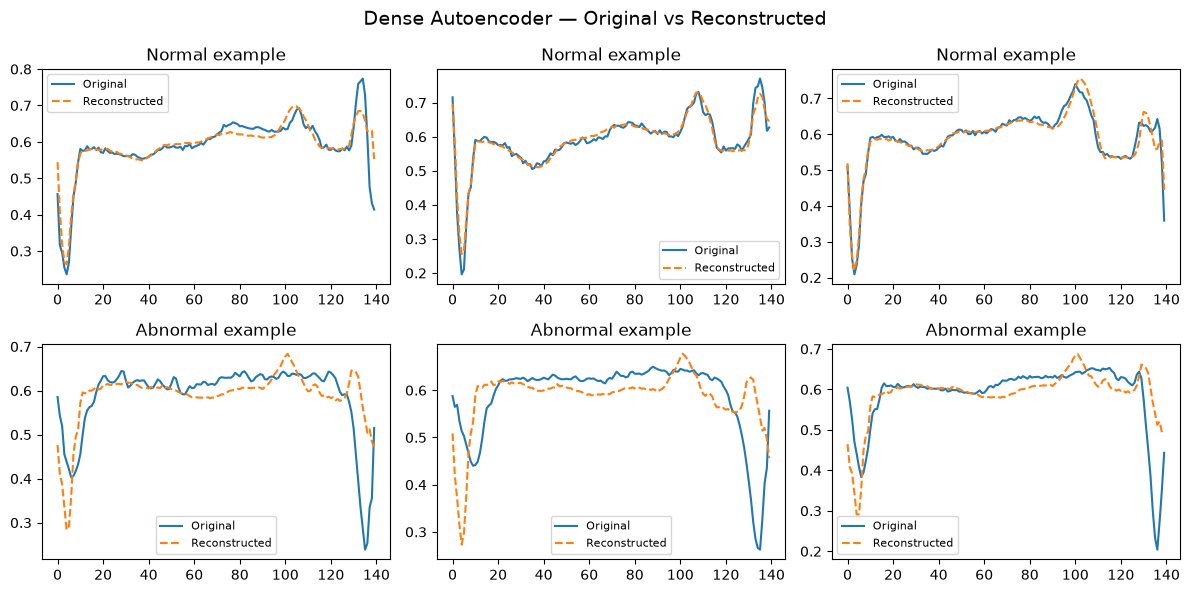

In [15]:
def plot_reconstructions(model, data, labels, n=3):
    normal_idx = np.where(labels == 1)[0][:n]
    abnormal_idx = np.where(labels == 0)[0][:n]

    fig, axes = plt.subplots(2, n, figsize=(4 * n, 6))
    fig.suptitle("Dense Autoencoder — Original vs Reconstructed", fontsize=14)

    for row, indices, title in [(0, normal_idx, "Normal example"),
                                (1, abnormal_idx, "Abnormal example")]:
        for col, idx in enumerate(indices):
            recon = model.predict(data[idx:idx+1], verbose=0).reshape(-1)
            axes[row, col].plot(data[idx], label="Original")
            axes[row, col].plot(recon, label="Reconstructed", linestyle="--")
            axes[row, col].set_title(title)
            axes[row, col].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

plot_reconstructions(dense_autoencoder, test_data, test_labels)


## 5. Conclusion

**Summary.** The Dense autoencoder was trained exclusively on normal ECG heartbeats, with the
scaler and the threshold derived from normal training data only. Reconstruction error (MAE)
was used as the anomaly score. The metrics printed above are the results of this run; they are
not hardcoded anywhere in the notebook.

**Limitations.**
- **Threshold sensitivity**: `mean + std` of normal training error is a simple heuristic, and it
  is computed on the same normal data the model was fitted on, so those errors can be slightly
  optimistic. Some normal beats are always flagged (false positives).
- **Test-set mix**: the test set is the 20% held-out normal beats plus *all* abnormal beats, so
  accuracy and precision depend on that mix. Prefer recall, F1 and AUC.
- **Dataset simplicity**: ECG5000 is pre-segmented and clean; results are **not** clinical-grade
  and this is an experimental/educational project, not a diagnostic system.
- **Single-class collapse**: abnormal labels 2-5 are merged; per-class detection is not analysed.
- **Single run**: one seed and one split; no confidence intervals; no hyperparameter search.
- **Reproducibility**: seeds fixed and deterministic ops enabled, but results may still differ
  slightly across hardware / library versions.

**Future improvements.** Validation-based threshold selection, multiple seeds /
cross-validation, per-class analysis, convolutional or variational autoencoders, noisier
real-world ECG.
